In [ ]:

import os
import shutil
import random

dataset_path = "recycling waste"   
output_path = "dataset_split"

train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

# Loop through each class (subfolder)
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    
    if not os.path.isdir(class_path):
        continue  
    
    # Create subfolders for each class in train/val/test
    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(output_path, split, class_name), exist_ok=True)

    # List all files in class folder
    files = os.listdir(class_path)
    random.shuffle(files)

    # Calculate split sizes
    train_size = int(len(files) * train_ratio)
    val_size = int(len(files) * val_ratio)

    train_files = files[:train_size]
    val_files = files[train_size:train_size + val_size]
    test_files = files[train_size + val_size:]

    # Helper function to copy files
    def move_files(file_list, split):
        for f in file_list:
            src = os.path.join(class_path, f)
            dst = os.path.join(output_path, split, class_name, f)
            shutil.copy(src, dst)   

    # Move files
    move_files(train_files, "train")
    move_files(val_files, "val")
    move_files(test_files, "test")

print("✅ Dataset successfully split into train/val/test with class subfolders!")



✅ Dataset successfully split into train/val/test with class subfolders!


Import the Libraries

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

Training the data set

In [22]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'dataset_split/train',
    labels='inferred',
    label_mode='categorical',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(128,128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=True
)

Found 5853 files belonging to 9 classes.


Traning the test data set

In [23]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'dataset_split/val',
    labels='inferred',
    label_mode='categorical',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(128,128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=True
)

Found 1670 files belonging to 9 classes.


Build the model

In [25]:
cnn = tf.keras.models.Sequential()

from PIL import Image
import os

dataset_path = "dataset_split/train"

for root, _, files in os.walk(dataset_path):
    for file in files:
        file_path = os.path.join(root, file)
        ext = os.path.splitext(file)[1].lower()
        if ext not in ['.jpg', '.jpeg', '.png']:
            os.remove(file_path)
            print(f"Removed non-image: {file_path}")
            continue
        try:
            with Image.open(file_path) as img:
                img.verify()
        except:
            print(f"Removed corrupted: {file_path}")
            os.remove(file_path)
!find "/dataset_split/train" -name ".*" -delete

for root, _, files in os.walk(dataset_path):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            im = Image.open(file_path).convert("RGB")
            im.save(file_path, "JPEG")
        except Exception as e:
            print(f"Failed converting: {file_path}, removing")
            os.remove(file_path)


File not found - -NAME
Access denied - .EBEXTENSIONS
File not found - -DELETE


In [26]:
import tensorflow as tf

cnn = tf.keras.models.Sequential()

# Convolution + Pooling Layers
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=(128,128,3)))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation='relu',input_shape=(128,128,3)))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3, activation='relu', input_shape=(128,128,3)))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=256, kernel_size=3, activation='relu',input_shape=(128,128,3)))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

# Flatten
cnn.add(tf.keras.layers.Flatten())

# Fully connected layer
cnn.add(tf.keras.layers.Dense(units=1024, activation='relu'))

# Output layer (9 classes)
cnn.add(tf.keras.layers.Dense(units=9, activation='softmax'))

# Compile
cnn.compile(optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy'])

#model summary
cnn.summary()
training_history = cnn.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=30
)



Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_20 (Conv2D)          (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d_20 (MaxPoolin  (None, 63, 63, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_21 (Conv2D)          (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_21 (MaxPoolin  (None, 30, 30, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_22 (Conv2D)          (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_22 (MaxPoolin  (None, 14, 14, 128)    

In [27]:
cnn.save('trained_model.h5')

In [28]:
cnn = tf.keras.models.load_model('trained_model.h5')

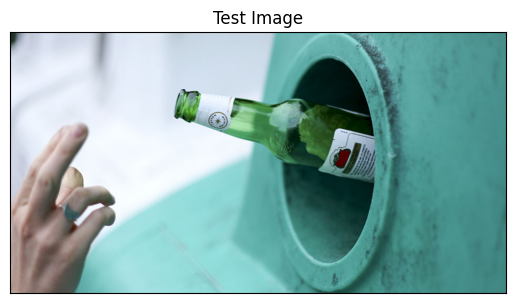

In [34]:
image_path = 'dataset_split/test/glass/Galsswaste.jpg'
img = plt.imread(image_path)
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])
plt.yticks([])
plt.show()

In [35]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr]) #converting single image to batch (2d dimention)
predictions = cnn.predict(input_arr)

1/1 [==============================] - 0s 39ms/step


In [37]:
predictions = cnn.predict(input_arr)
print(predictions)
pred_index = np.argmax(predictions[0])
class_labels = training_set.class_names
print("Predicted Class:", class_labels[pred_index])

1/1 [==============================] - 0s 38ms/step
[[1.9888813e-03 7.2994176e-08 1.2660238e-03 3.3460424e-04 5.5217836e-04
  7.8098887e-01 1.3208848e-10 2.1486905e-01 3.1261288e-07]]
Predicted Class: metal


Final model train

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
img_size = (128, 128)
batch_size = 32

train_ds = image_dataset_from_directory(
"dataset_split/train",
image_size=img_size,
batch_size=batch_size,
label_mode="categorical"
)

val_ds = image_dataset_from_directory(
"dataset_split/val",
image_size=img_size,
batch_size=batch_size,
label_mode="categorical"
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 5853 files belonging to 9 classes.
Found 1670 files belonging to 9 classes.
Classes: ['batteries', 'clothes', 'e-waste', 'glass', 'light blubs', 'metal', 'organic', 'paper', 'plastic']


In [5]:
train_ds = train_ds.map(lambda x, y: (x/255.0, y))
val_ds = val_ds.map(lambda x, y: (x/255.0, y))

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
input_shape=img_size + (3,),
include_top=False,
weights="imagenet"
)
base_model.trainable = False # Freeze base layers

cnn = models.Sequential([
base_model,
layers.GlobalAveragePooling2D(),
layers.Dense(256, activation="relu"),
layers.Dropout(0.5),
layers.Dense(len(class_names), activation="softmax") # number of classes
])

cnn.compile(
optimizer="adam",
loss="categorical_crossentropy",
metrics=["accuracy"]
)
cnn.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_128 (Func  (None, 4, 4, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d_3  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_5 (Dense)             (None, 256)               327936    
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 dense_6 (Dense)             (None, 9)                 2313      
                                                                 
Total params: 2588233 (9.87 MB)
Trainable params: 3302

In [11]:
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = cnn.fit(
train_ds,
validation_data=val_ds,
epochs=30,
callbacks=[early_stop]
)

Epoch 1/30
183/183 [==============================] - 143s 767ms/step - loss: 0.3272 - accuracy: 0.8836 - val_loss: 0.6646 - val_accuracy: 0.8024
Epoch 2/30
183/183 [==============================] - 118s 642ms/step - loss: 0.2864 - accuracy: 0.9019 - val_loss: 0.6698 - val_accuracy: 0.7850
Epoch 3/30
183/183 [==============================] - 135s 736ms/step - loss: 0.2181 - accuracy: 0.9233 - val_loss: 0.6953 - val_accuracy: 0.7994
Epoch 4/30
183/183 [==============================] - 130s 708ms/step - loss: 0.1829 - accuracy: 0.9371 - val_loss: 0.6937 - val_accuracy: 0.8048
Epoch 5/30
183/183 [==============================] - 98s 535ms/step - loss: 0.1726 - accuracy: 0.9409 - val_loss: 0.7051 - val_accuracy: 0.7982
Epoch 6/30
183/183 [==============================] - 183s 1000ms/step - loss: 0.1599 - accuracy: 0.9446 - val_loss: 0.7221 - val_accuracy: 0.8036


In [6]:
cnn.save("waste_classifier_mobilenetv2.h5")

In [8]:
cnn = tf.keras.models.load_model('waste_classifier_mobilenetv2.h5')

In [54]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_size = (128, 128)
img_path = "dataset_split/test/batteries/ecology-recycling-concept-many-different-types-used-new-batt-ecology-recycling-concept-many-different-types-used-new-battery-125891684.jpg" # example test image
img = image.load_img(img_path, target_size=img_size)
input_arr = image.img_to_array(img) / 255.0
input_arr = np.expand_dims(input_arr, axis=0)

predictions = cnn.predict(input_arr)
pred_index = np.argmax(predictions[0])
print("Predicted Class:", class_names[pred_index])

1/1 [==============================] - 1s 781ms/step
Predicted Class: batteries


Analysis for mid review

IMPORT LIBRARIES

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import itertools
from random import randint


LOAD DATASET

In [13]:
img_size = (128, 128)
batch_size = 32

train_ds = image_dataset_from_directory(
    "dataset_split/train",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

val_ds = image_dataset_from_directory(
    "dataset_split/val",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

class_names = train_ds.class_names
print("Classes:", class_names)

# Normalize images
train_ds = train_ds.map(lambda x, y: (x/255.0, y))
val_ds = val_ds.map(lambda x, y: (x/255.0, y))

Found 5853 files belonging to 9 classes.
Found 1670 files belonging to 9 classes.
Classes: ['batteries', 'clothes', 'e-waste', 'glass', 'light blubs', 'metal', 'organic', 'paper', 'plastic']


ANALYSING SAMPLE SIZE OF EACH TARGET

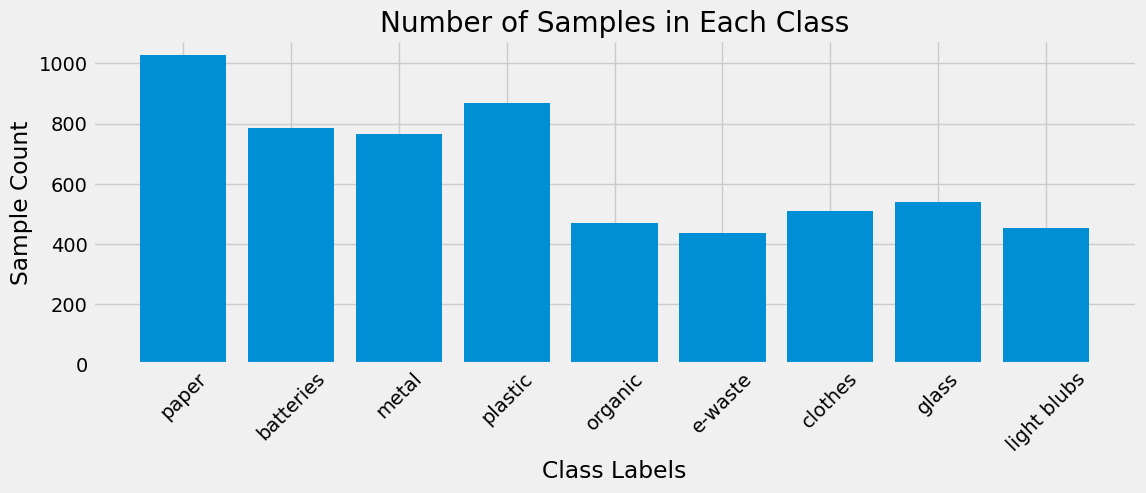

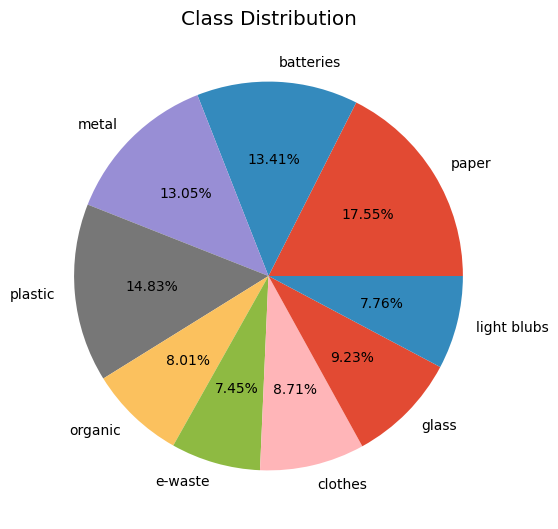

In [14]:
# Count samples
train_count = {}
for images, labels in train_ds.unbatch():
    label_index = np.argmax(labels.numpy())
    label_name = class_names[label_index]
    train_count[label_name] = train_count.get(label_name, 0) + 1

labels = list(train_count.keys())
sizes = list(train_count.values())

# ---------- BAR CHART ----------
plt.style.use("fivethirtyeight")
plt.figure(figsize=(12, 4))
plt.bar(labels, sizes)
plt.title("Number of Samples in Each Class")
plt.xlabel("Class Labels")
plt.ylabel("Sample Count")
plt.xticks(rotation=45)
plt.show()

# ---------- PIE CHART ----------
plt.style.use("ggplot")
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct="%.2f%%")
plt.title("Class Distribution")
plt.show()


SHOW SAMPLE IMAGES

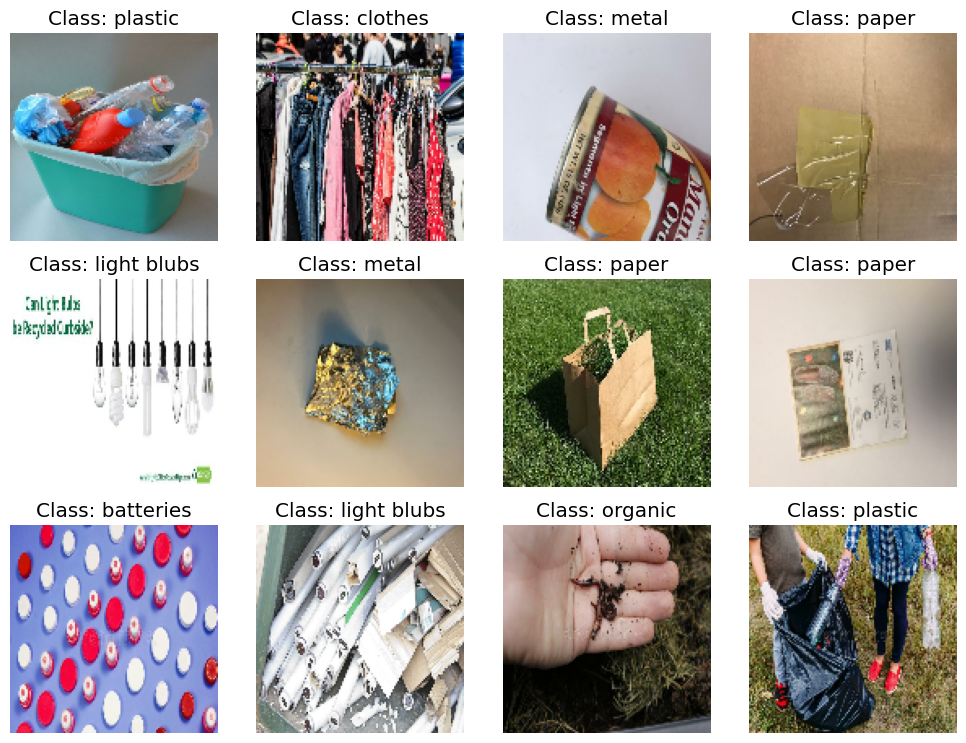

In [17]:
def show_images_from_dataset(dataset, class_labels):
    plt.figure(figsize=(10, 10))
    dataset = list(dataset.unbatch().take(200))

    for i in range(12):
        ax = plt.subplot(4, 4, i + 1)
        idx = randint(0, len(dataset) - 1)
        img, label = dataset[idx]
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Class: {class_labels[np.argmax(label.numpy())]}")

    plt.tight_layout()
    plt.show()

show_images_from_dataset(train_ds, class_names)

BUILD MODEL

In [21]:
base_model = tf.keras.applications.MobileNetV2(
input_shape=img_size + (3,),
include_top=False,
weights="imagenet"
)
base_model.trainable = False # Freeze base layers

cnn = models.Sequential([
base_model,
layers.GlobalAveragePooling2D(),
layers.Dense(256, activation="relu"),
layers.Dropout(0.5),
layers.Dense(len(class_names), activation="softmax") # number of classes
])

cnn.compile(
optimizer="adam",
loss="categorical_crossentropy",
metrics=["accuracy"]
)
cnn.summary()
   


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_128 (Func  (None, 4, 4, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d_4  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_7 (Dense)             (None, 256)               327936    
                                                                 
 dropout_3 (Dropout)         (None, 256)               0         
                                                                 
 dense_8 (Dense)             (None, 9)                 2313      
                                                                 
Total params: 2588233 (9.87 MB)
Trainable params: 3302

TRAIN THE MODEL

In [ ]:
early_stop = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

history = cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_stop]
)

SAVE & LOAD MODEL

In [ ]:
cnn.save("waste_classifier.h5")
cnn = tf.keras.models.load_model("waste_classifier.h5")

c:\Users\Admin\.conda\envs\myenv\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


ACCURACY & LOSS CURVES

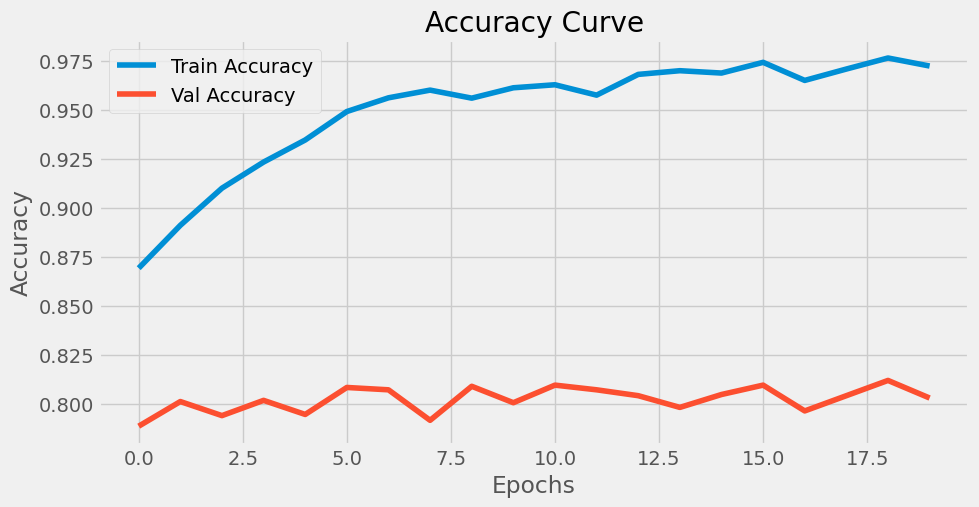

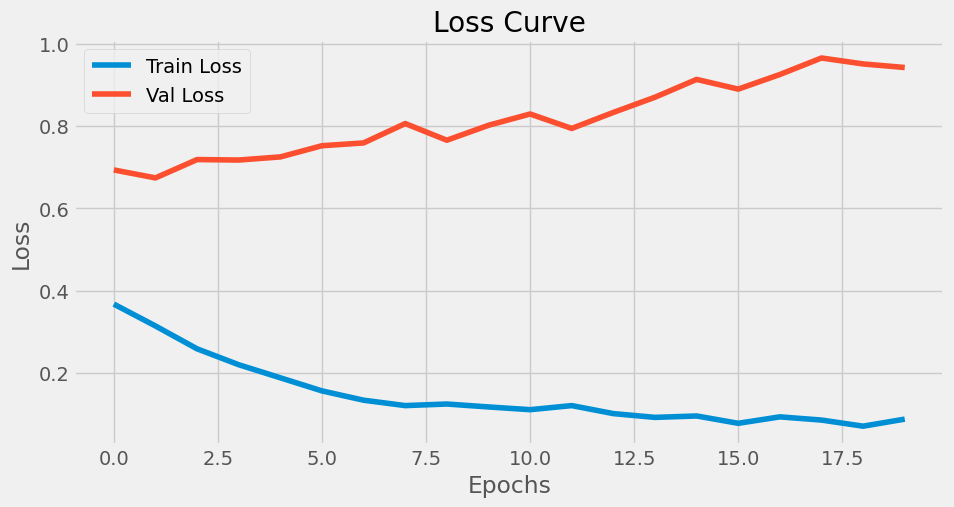

In [ ]:
plt.style.use("fivethirtyeight")

# Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

CONFUSION MATRIX + CLASSIFICATION REPORT

1/1 [==============================] - 2s 2s/step


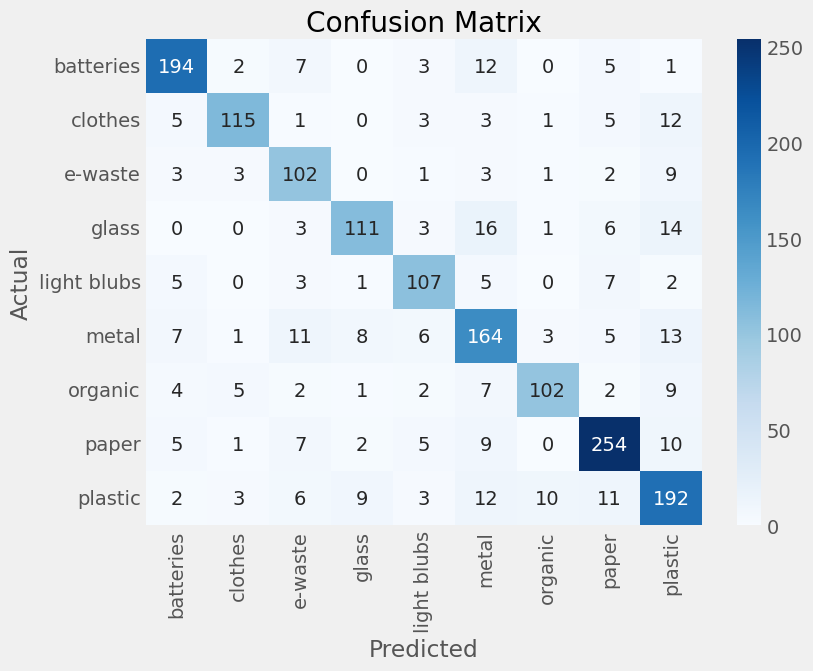


CLASSIFICATION REPORT:

              precision    recall  f1-score   support

   batteries       0.86      0.87      0.86       224
     clothes       0.88      0.79      0.84       145
     e-waste       0.72      0.82      0.77       124
       glass       0.84      0.72      0.78       154
 light blubs       0.80      0.82      0.81       130
       metal       0.71      0.75      0.73       218
     organic       0.86      0.76      0.81       134
       paper       0.86      0.87      0.86       293
     plastic       0.73      0.77      0.75       248

    accuracy                           0.80      1670
   macro avg       0.81      0.80      0.80      1670
weighted avg       0.81      0.80      0.80      1670



In [30]:
# Convert validation data to predictions
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = cnn.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names, 
            yticklabels=class_names,
            cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nCLASSIFICATION REPORT:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

 final training and validation accuracy

In [31]:
# Print final training and validation accuracy
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {train_acc*100:.2f}%")
print(f"Final Validation Accuracy: {val_acc*100:.2f}%")

Final Training Accuracy: 97.25%
Final Validation Accuracy: 80.30%


Check final

In [ ]:

from tensorflow.keras.preprocessing import image
image_path = 'dataset_split/test/glass/Galsswaste.jpg'

# Load and preprocess the image
img = image.load_img(image_path, target_size=(128, 128))
input_arr = image.img_to_array(img) / 255.0
input_arr = np.expand_dims(input_arr, axis=0)

# Make prediction
predictions = cnn.predict(input_arr)
pred_index = np.argmax(predictions[0])
pred_class = class_names[pred_index]
confidence = predictions[0][pred_index] * 100  # percentage

# Display the image with label and confidence
plt.imshow(plt.imread(image_path))
plt.title(f"Predicted: {pred_class} ({confidence:.2f}%)")
plt.axis('off')  # remove axes
plt.show()

In [39]:
# Example: convert one-hot to integer labels if needed
y_true = np.argmax(y_val, axis=1)  # if val labels are categorical
y_pred = np.argmax(cnn.predict(val_ds), axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

NameError: name 'y_val' is not defined